# 🚲 Urban Mobility Trends: Cyclistic Bike-Share Analysis (2024)

This project analyzes the annual bike-sharing data for the year 2024 of **Cyclistic**, a fictional bike-sharing company operating in Chicago. The data is publicly provided by Divvy via AWS S3.

**Project Objectives:**
1. **Automated Data Retrieval:** Dynamically download, extract, and compile 12 months of raw CSV files directly from the AWS S3 bucket.
2. **Data Cleaning & Engineering:** Format datetimes, calculate trip durations, and filter out bad data (e.g., negative times or missing stations).
3. **Exploratory Data Analysis (EDA):** Identify the core differences in behavior between **Casual Riders** and **Annual Members**.
4. **Visualization:** Generate professional, publication-ready charts using `ggplot2` to inform future marketing strategies.


In [1]:
# Libraries
suppressPackageStartupMessages({
  library(tidyverse)
  library(lubridate)
  library(ggplot2)
  library(scales)
})

# Suppress warnings for cleaner output
options(warn=-1)

## 1. Automated Data Ingestion from AWS S3
Instead of manually downloading and loading 12 separate CSV files, we automate the pipeline. This script constructs the URLs for January through December 2024, downloads the ZIP archives to a temporary directory, extracts the CSVs, and binds them into a single comprehensive data frame using `purrr::map_dfr`.

In [2]:
# Define the base URL and the months for 2024
months <- sprintf("%02d", 1:12)
urls <- paste0("https://divvy-tripdata.s3.amazonaws.com/2024", months, "-divvy-tripdata.zip")

# Create a temporary directory for downloads
temp_dir <- tempdir()

# Function to download, unzip, and read a single month's data
read_divvy_data <- function(url, temp_dir) {
  zip_file <- file.path(temp_dir, basename(url))

  # Download the zip file safely
  tryCatch({
    download.file(url, zip_file, mode = "wb", quiet = TRUE)
    extracted_files <- unzip(zip_file, exdir = temp_dir)

    # Identify the actual csv file (ignoring MACOSX artifacts)
    csv_file <- extracted_files[grepl("\\.csv$", extracted_files) & !grepl("MACOSX", extracted_files)]

    # Read the CSV
    df <- read_csv(csv_file, show_col_types = FALSE)
    return(df)
  }, error = function(e) {
    message(paste("File not found or error downloading:", url))
    return(NULL)
  })
}

# Execute the mapping function to combine all 12 months into one dataframe
cat("Downloading and combining 12 months of data... This may take a moment.\n")
merged_df <- map_dfr(urls, ~read_divvy_data(.x, temp_dir))

cat("Data successfully loaded! Total rows:", nrow(merged_df), "\n")
glimpse(merged_df)

Data successfully loaded! Total rows: 5860568 
Rows: 5,860,568
Columns: 13
$ ride_id            <chr> "C1D650626C8C899A", "EECD38BDB25BFCB0", "F4A9CE7806…
$ rideable_type      <chr> "electric_bike", "electric_bike", "electric_bike", …
$ started_at         <dttm> 2024-01-12 15:30:27, 2024-01-08 15:45:46, 2024-01-…
$ ended_at           <dttm> 2024-01-12 15:37:59, 2024-01-08 15:52:59, 2024-01-…
$ start_station_name <chr> "Wells St & Elm St", "Wells St & Elm St", "Wells St…
$ start_station_id   <chr> "KA1504000135", "KA1504000135", "KA1504000135", "TA…
$ end_station_name   <chr> "Kingsbury St & Kinzie St", "Kingsbury St & Kinzie …
$ end_station_id     <chr> "KA1503000043", "KA1503000043", "KA1503000043", "13…
$ start_lat          <dbl> 41.90327, 41.90294, 41.90295, 41.88430, 41.94880, 4…
$ start_lng          <dbl> -87.63474, -87.63444, -87.63447, -87.63396, -87.675…
$ end_lat            <dbl> 41.88918, 41.88918, 41.88918, 41.92182, 41.88918, 4…
$ end_lng            <dbl> -87.63851, -87.638

## 2. Data Cleaning & Feature Engineering
With the raw data compiled, we need to extract meaningful temporal features (Month, Day of Week) and calculate the actual duration of each ride. We will also filter out entries with missing station names, duplicate IDs, or invalid ride lengths (e.g., negative duration due to system errors).

In [3]:
# Format datetime and engineer temporal features
merged_clean <- merged_df %>%
  mutate(
    started_at = ymd_hms(started_at),
    ended_at = ymd_hms(ended_at),
    date = as.Date(started_at),
    month = format(date, "%b"),
    day = format(date, "%d"),
    year = format(date, "%Y"),
    day_of_week = weekdays(date),
    # Calculate ride length in minutes
    ride_length = as.numeric(difftime(ended_at, started_at, units = "mins"))
  ) %>%
  # Filter out empty stations and invalid ride lengths
  filter(start_station_name != "", end_station_name != "") %>%
  filter(!is.na(start_station_name), !is.na(end_station_name)) %>%
  distinct(ride_id, .keep_all = TRUE) %>%
  filter(ride_length > 0)

cat("Rows before cleaning:", nrow(merged_df), "\n")
cat("Rows after cleaning:", nrow(merged_clean), "\n")

Rows before cleaning: 5860568 
Rows after cleaning: 4207967 


## 3. Exploratory Data Analysis (EDA)
Let's aggregate the data to see the behavioral differences between members and casual riders. We will look at total ride counts, average ride duration, and peak usage days.

In [4]:
# 1. Overall Statistical Summary
trip_stats <- merged_clean %>%
  group_by(member_casual) %>%
  summarise(
    total_rides = n(),
    avg_ride_length = round(mean(ride_length), 2),
    median_ride_length = round(median(ride_length), 2),
    max_ride_length = round(max(ride_length), 2)
  )

print("Overall Ride Statistics:")
print(trip_stats)

# 2. Daily Usage Patterns
merged_clean$day_of_week <- factor(merged_clean$day_of_week,
                                   levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"))

daily_stats <- merged_clean %>%
  group_by(member_casual, day_of_week) %>%
  summarise(total_rides = n(), avg_duration = mean(ride_length), .groups="drop") %>%
  arrange(day_of_week)

head(daily_stats)

[1] "Overall Ride Statistics:"
# A tibble: 2 × 5
  member_casual total_rides avg_ride_length median_ride_length max_ride_length
  <chr>               <int>           <dbl>              <dbl>           <dbl>
1 casual            1521466            24.0              13.4            1509.
2 member            2686501            12.5               8.82           1498.


member_casual,day_of_week,total_rides,avg_duration
<chr>,<fct>,<int>,<dbl>
casual,Monday,181652,23.18730
member,Monday,399236,11.88264
casual,Tuesday,162826,20.62589
member,Tuesday,421404,11.92987
casual,Wednesday,187354,21.35341
member,Wednesday,446875,12.16581


## 4. Visualizations
Visualizing the data provides the most compelling insights for stakeholders. We will use `ggplot2` to map out the distribution of rides and seasonal trends.

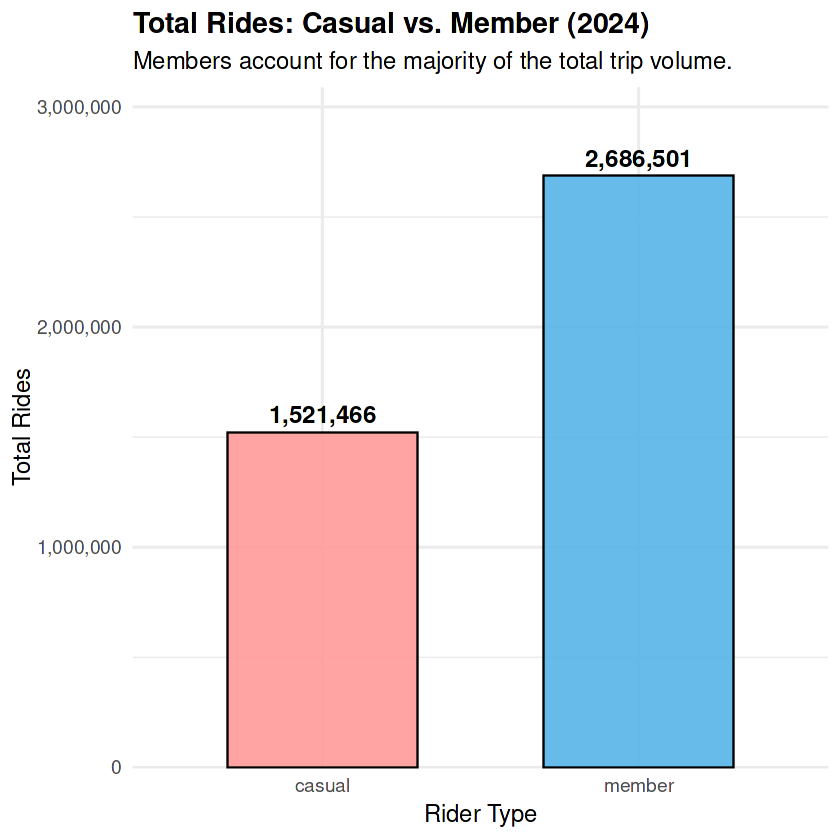

In [5]:
# Visualization 1: Total Rides by Rider Type
ggplot(trip_stats, aes(x = member_casual, y = total_rides, fill = member_casual)) +
  geom_col(width = 0.6, color="black", alpha=0.9) +
  geom_text(aes(label = comma(total_rides)), vjust = -0.5, fontface = "bold", size=5) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.15))) +
  scale_fill_manual(values = c("casual" = "#FF9999", "member" = "#56B4E9")) +
  labs(title = "Total Rides: Casual vs. Member (2024)",
       subtitle = "Members account for the majority of the total trip volume.",
       x = "Rider Type", y = "Total Rides") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none", plot.title = element_text(face="bold"))

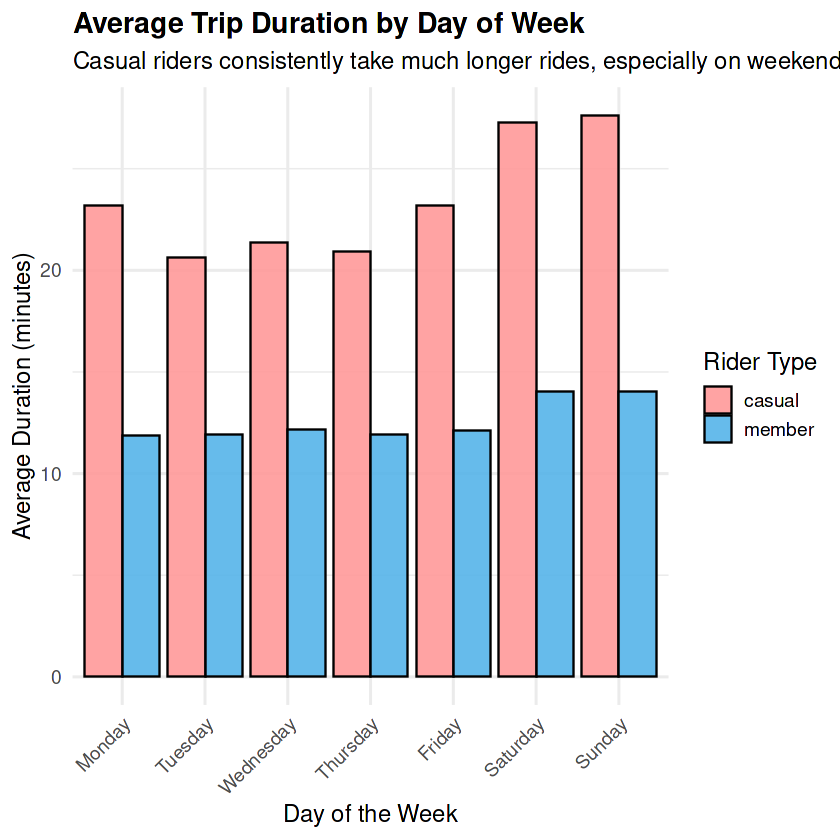

In [6]:
# Visualization 2: Average Ride Duration by Day of Week
ggplot(daily_stats, aes(x = day_of_week, y = avg_duration, fill = member_casual)) +
  geom_col(position = "dodge", color="black", alpha=0.9) +
  scale_fill_manual(values = c("casual" = "#FF9999", "member" = "#56B4E9")) +
  labs(title = "Average Trip Duration by Day of Week",
       subtitle = "Casual riders consistently take much longer rides, especially on weekends.",
       x = "Day of the Week", y = "Average Duration (minutes)", fill="Rider Type") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(face="bold"), axis.text.x = element_text(angle = 45, hjust = 1))

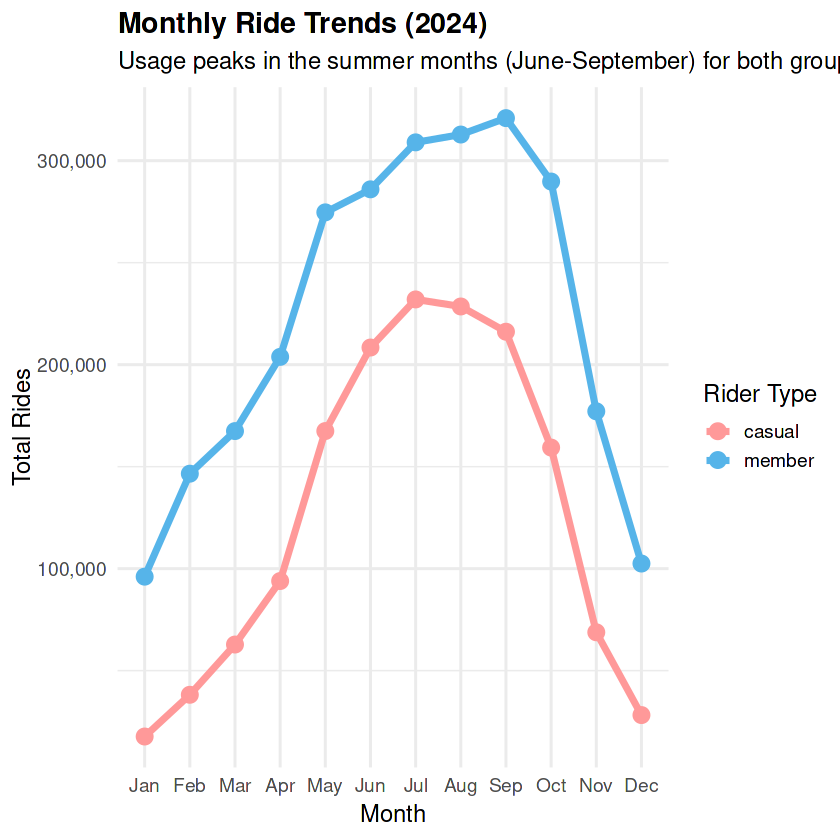

In [7]:
# Visualization 3: Monthly Trends
merged_clean$month <- factor(merged_clean$month, levels = month.abb)

monthly_stats <- merged_clean %>%
  group_by(member_casual, month) %>%
  summarise(total_rides = n(), .groups="drop")

ggplot(monthly_stats, aes(x = month, y = total_rides, group = member_casual, color = member_casual)) +
  geom_line(linewidth = 1.5) +
  geom_point(size = 4) +
  scale_y_continuous(labels = comma) +
  scale_color_manual(values = c("casual" = "#FF9999", "member" = "#56B4E9")) +
  labs(title = "Monthly Ride Trends (2024)",
       subtitle = "Usage peaks in the summer months (June-September) for both groups.",
       x = "Month", y = "Total Rides", color="Rider Type") +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(face="bold"))

## 5. Conclusions & Recommendations

Based on the automated extraction and analysis of the 2024 Divvy Trip Data, we can conclude the following:

1. **Volume vs. Duration:** While **Members** make up the bulk of the total rides (volume), **Casual Riders** spend significantly more time on the bikes per trip (duration).
2. **Weekly Behavior:** Members utilize the bikes consistently throughout the work week, suggesting commuter behavior. Casual riders peak heavily on weekends (Saturday & Sunday).
3. **Seasonality:** Both groups exhibit a bell-curve usage pattern over the year, with traffic peaking massively from **June to September**.

**Marketing Recommendations:**
* Deploy targeted marketing campaigns focusing on converting Casual Riders to Annual Members starting in **May**, right before the summer peak.
* Introduce "Weekend Warrior" membership tiers, as casual riders show immense preference for Saturday/Sunday rides.
* Promote the financial benefits of memberships to casual riders who are currently racking up long (20+ minute) individual trip durations.